# ISSP exploratory data analysis

This notebook explores the constructed ISSP dataset for the Swytch project. It focuses on the main outcome (`job_satisfaction`), key demographic variables, work patterns, and the value-based items that can later be linked to person-job fit features.

The notebook is designed to answer a few practical questions before modeling:
- what does the sample look like?
- how much missing data is there?
- how is job satisfaction distributed?
- do work values and job circumstances differ by sex, age, or country?
- how much occupation-code coverage is available for later O*NET linkage?


In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

candidates = [
    Path('../../data/constructed_datasets/issp.csv'),
    Path('data/constructed_datasets/issp.csv'),
    Path.cwd() / 'data' / 'constructed_datasets' / 'issp.csv',
]
data_path = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(data_path)

print(f'CSV path: {data_path}')
print(f'Shape: {df.shape}')
df.head()


CSV path: ../../data/constructed_datasets/issp.csv
Shape: (122003, 114)


,study_no,archive_version,doi,case_id,cumu_id,module_year,country,country_sample,country_sample_year,time_paid_job,...,voted_last_election,religious_attendance,religion_group,social_status_scale,subjective_class,urban_rural,household_income_group,weight,data_collection_mode,ONET_SOC_CODE
0,8797.0,1.0.0 (2024-10-07),https://doi.org/10.4232/1.14391,1000001.0,2005000360000001,2005.0,36.0,36.0,362005.0,5.0,...,1.0,5.0,2.0,2.0,NaN,5.0,NaN,1.0,34.0,NaN
1,8797.0,1.0.0 (2024-10-07),https://doi.org/10.4232/1.14391,1000002.0,2005000360000002,2005.0,36.0,36.0,362005.0,1.0,...,1.0,6.0,2.0,3.0,NaN,2.0,NaN,1.0,34.0,45-1011.00
2,8797.0,1.0.0 (2024-10-07),https://doi.org/10.4232/1.14391,1000003.0,2005000360000003,2005.0,36.0,36.0,362005.0,4.0,...,1.0,2.0,2.0,6.0,NaN,1.0,2.0,1.0,34.0,NaN
3,8797.0,1.0.0 (2024-10-07),https://doi.org/10.4232/1.14391,1000004.0,2005000360000004,2005.0,36.0,36.0,362005.0,4.0,...,1.0,5.0,2.0,7.0,NaN,1.0,3.0,1.0,34.0,43-3031.00
4,8797.0,1.0.0 (2024-10-07),https://doi.org/10.4232/1.14391,1000005.0,2005000360000005,2005.0,36.0,36.0,362005.0,4.0,...,1.0,5.0,2.0,8.0,NaN,2.0,3.0,1.0,34.0,11-3071.00


## 1) Quick structure and data types

This step checks the table shape and the major columns that will drive downstream analysis.

In [10]:
print(df.dtypes.head(20).to_string())
print('\nColumns of interest:')
cols = [
    'country', 'sex', 'age', 'marital_status', 'educ_years', 'employment_status_current',
    'hours_worked_weekly', 'job_satisfaction', 'imp_job_security', 'imp_income',
    'imp_advancement', 'imp_independence', 'imp_help_others', 'imp_useful_society',
    'actual_job_secure', 'actual_job_interesting', 'ONET_SOC_CODE'
]
print([c for c in cols if c in df.columns])


study_no                        float64
archive_version                  object
doi                              object
case_id                         float64
cumu_id                           int64
module_year                     float64
country                         float64
country_sample                  float64
country_sample_year             float64
time_paid_job                   float64
time_housework                  float64
time_family                     float64
time_friends                    float64
time_leisure                    float64
job_just_for_money              float64
would_work_without_need         float64
work_most_important_activity    float64
domestic_duties                 float64
unions_needed                   float64
imp_job_security                float64

Columns of interest:
['country', 'sex', 'age', 'marital_status', 'educ_years', 'employment_status_current', 'hours_worked_weekly', 'job_satisfaction', 'imp_job_security', 'imp_income', 'imp_advanceme

## 2) Missingness profile

There are many survey items with substantial missingness, especially for detailed work and job-history questions. This matters because a modeling pipeline will need to choose a sensible missing-data strategy.

n_supervised                  0.911830
training_not_working_12mo     0.817668
how_hard_works                0.788202
second_job                    0.763227
year_last_job_ended           0.740015
likely_find_job               0.737162
reason_job_ended              0.735720
advertised_self               0.720163
registered_private_agency     0.719982
answered_job_ad               0.718892
applied_directly_employers    0.718769
asked_relatives_friends       0.718351
registered_public_agency      0.717130
currently_looking_for_job     0.712925
subjective_class              0.693212
would_change_type_of_work     0.691368
proud_of_work_type            0.685696
easy_find_acceptable_job      0.662017
avoid_unemp_lower_pay         0.659353
avoid_unemp_travel_longer     0.659197


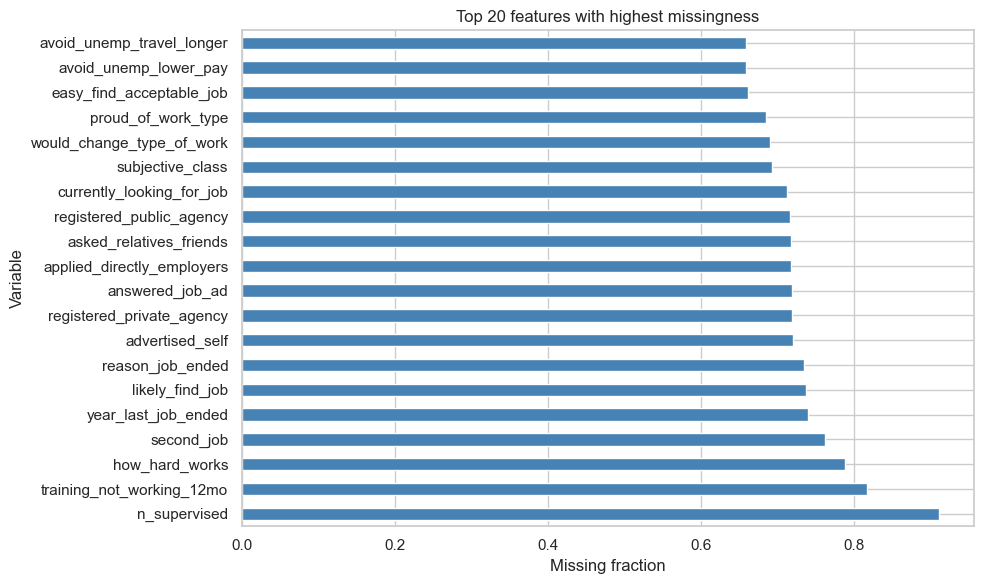

In [11]:
missing_summary = df.isna().mean().sort_values(ascending=False).head(20)
print(missing_summary.to_string())

plt.figure(figsize=(10, 6))
missing_summary.plot(kind='barh', color='steelblue')
plt.title('Top 20 features with highest missingness')
plt.xlabel('Missing fraction')
plt.ylabel('Variable')
plt.tight_layout()


## 3) Outcome: job satisfaction distribution

The target variable is a 1-7 satisfaction scale. We inspect both the raw distribution and the share of sample with a non-missing response.

Non-missing job satisfaction responses: 68929 / 122003
job_satisfaction
1.0     9873
2.0    20026
3.0    26339
4.0     7730
5.0     3228
6.0     1112
7.0      621


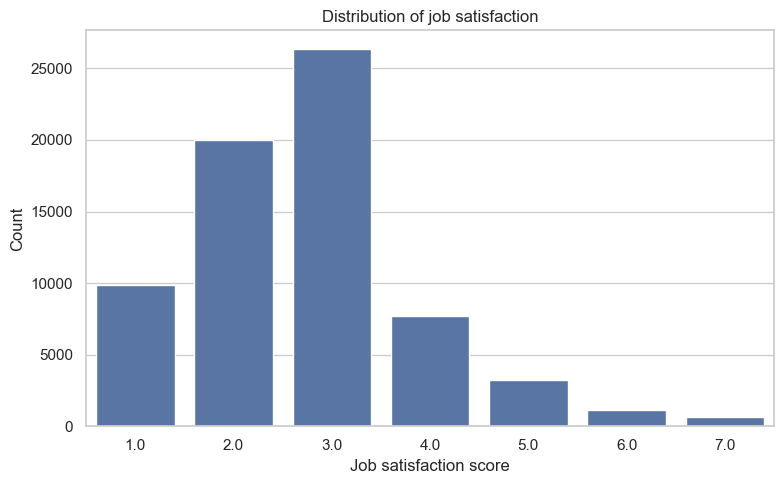

In [12]:
satisfaction = df['job_satisfaction'].dropna()
print(f'Non-missing job satisfaction responses: {len(satisfaction)} / {len(df)}')
print(satisfaction.value_counts().sort_index().to_string())

plt.figure(figsize=(8, 5))
sns.countplot(data=df.dropna(subset=['job_satisfaction']), x='job_satisfaction', order=sorted(df['job_satisfaction'].dropna().unique()))
plt.title('Distribution of job satisfaction')
plt.xlabel('Job satisfaction score')
plt.ylabel('Count')
plt.tight_layout()


## 4) Demographics

This sample spans many countries and a wide age range, so it is useful to understand the respondent structure before comparing work values and satisfaction patterns.

Sex counts:
sex
Female    65561
Male      56219
NaN         223
Top countries by count:
country
578.0    6919
276.0    6709
710.0    5824
840.0    5676
376.0    5098
826.0    5083
643.0    4899
528.0    4882
756.0    4831
348.0    4515
724.0    4248
158.0    4202


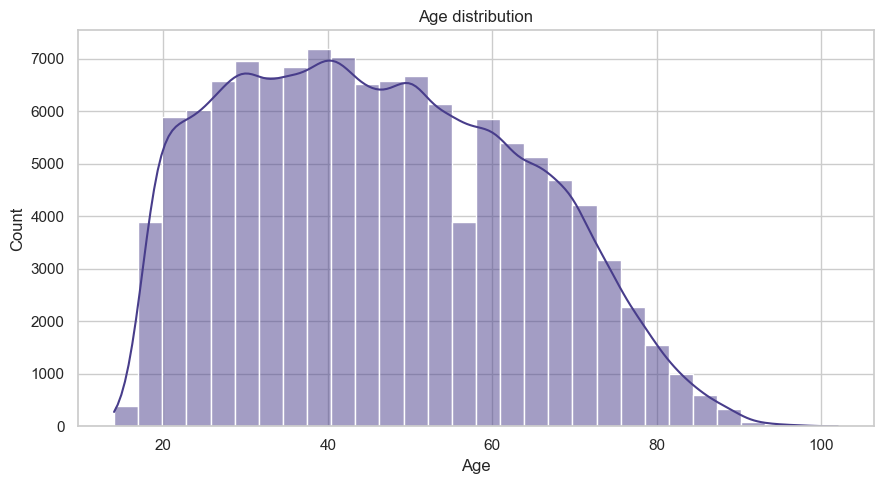

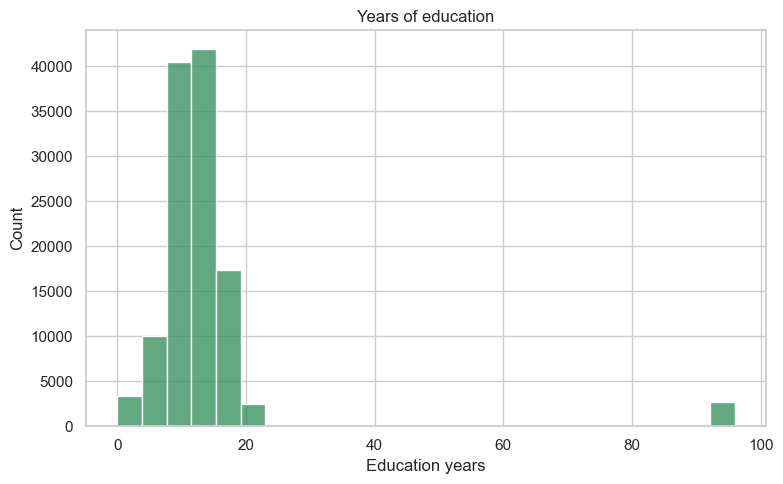

In [13]:
# Age distribution
plt.figure(figsize=(9, 5))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='darkslateblue')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()

# Sex breakdown
sex_labels = {1: 'Male', 2: 'Female'}
sex_counts = df['sex'].map(sex_labels).value_counts(dropna=False)
print('Sex counts:')
print(sex_counts.to_string())

# Country counts
country_counts = df['country'].value_counts().head(12)
print('Top countries by count:')
print(country_counts.to_string())

# Education distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['educ_years'].dropna(), bins=25, color='seagreen')
plt.title('Years of education')
plt.xlabel('Education years')
plt.ylabel('Count')
plt.tight_layout()


## 5) Work conditions and employment status

Here we inspect how respondents are employed and how the number of hours worked varies across the full sample.

Employment status counts:
employment_status_current
1.0    67987
5.0    21343
6.0    11217
2.0     7856
3.0     6101
4.0     3055
8.0     2702
NaN     1710
7.0       32

Average job satisfaction by employment status:
employment_status_current
7.0    3.909091
2.0    3.301887
3.0    2.820024
8.0    2.786378
6.0    2.746702
NaN    2.744538
1.0    2.710700
4.0    2.695238
5.0    2.367758


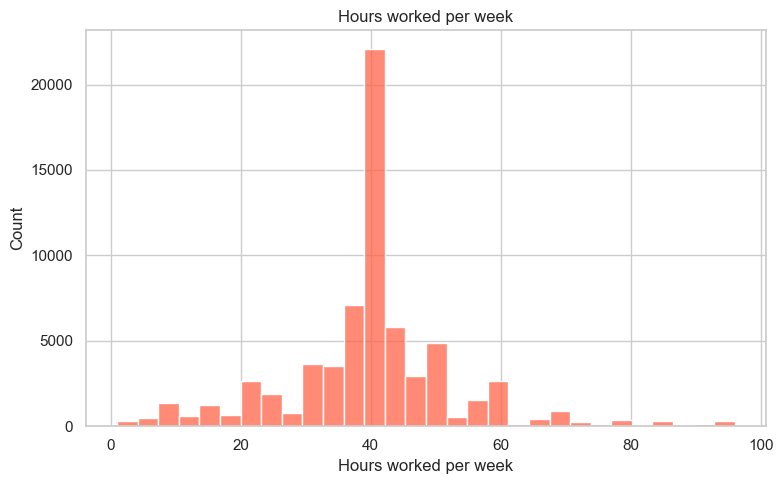

In [14]:
status_counts = df['employment_status_current'].value_counts(dropna=False).head(10)
print('Employment status counts:')
print(status_counts.to_string())

plt.figure(figsize=(8, 5))
sns.histplot(df['hours_worked_weekly'].dropna(), bins=30, color='tomato')
plt.title('Hours worked per week')
plt.xlabel('Hours worked per week')
plt.ylabel('Count')
plt.tight_layout()

# Compare average satisfaction by employment status
status_satisfaction = df.groupby('employment_status_current', dropna=False)['job_satisfaction'].mean().sort_values(ascending=False)
print('\nAverage job satisfaction by employment status:')
print(status_satisfaction.to_string())


## 6) Work values and job priorities

The dataset contains several items representing the importance of job attributes such as security, income, autonomy, and social impact. These are the primary ingredients for person-job fit scoring later in the project.

Average rating by work-value item:
actual_job_secure         2.316634
actual_job_interesting    2.148964
imp_advancement           2.089368
imp_help_others           2.034899
imp_independence          2.024174
imp_useful_society        2.020816
imp_income                1.943998
imp_job_security          1.506769


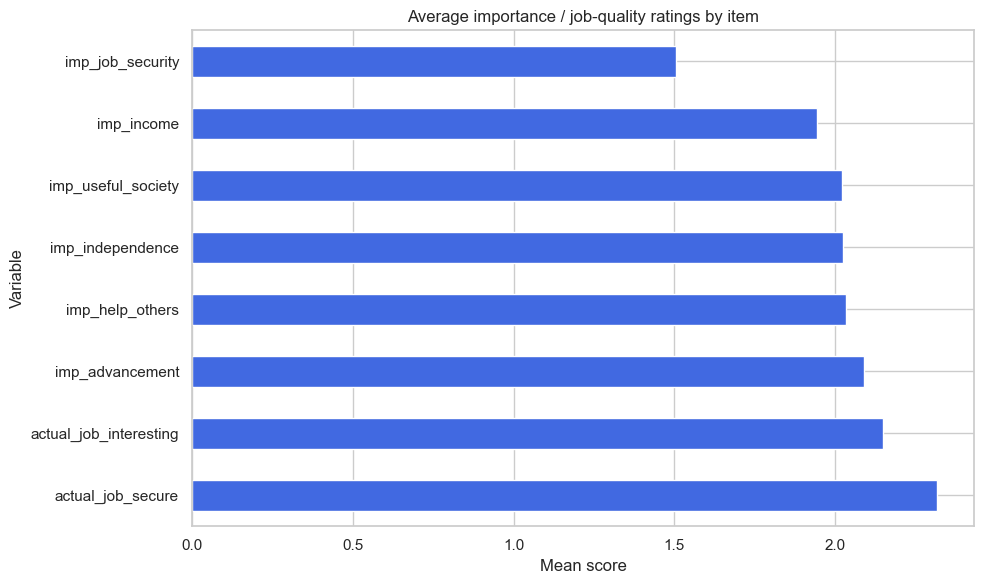

In [15]:
value_cols = [
    'imp_job_security', 'imp_income', 'imp_advancement', 'imp_independence',
    'imp_help_others', 'imp_useful_society', 'actual_job_secure', 'actual_job_interesting'
]

value_stats = df[value_cols].mean().sort_values(ascending=False)
print('Average rating by work-value item:')
print(value_stats.to_string())

plt.figure(figsize=(10, 6))
value_stats.plot(kind='barh', color='royalblue')
plt.title('Average importance / job-quality ratings by item')
plt.xlabel('Mean score')
plt.ylabel('Variable')
plt.tight_layout()


## 7) Occupation-code coverage

The project later connects the survey to O*NET occupation profiles. This requires a usable occupation code for each respondent.

In [16]:
onet_coverage = df['ONET_SOC_CODE'].notna().mean()
print(f'Fraction of respondents with an O*NET SOC code: {onet_coverage:.2%}')

top_occupations = df['ONET_SOC_CODE'].value_counts(dropna=False).head(10)
print('Most common O*NET SOC codes:')
print(top_occupations.to_string())

# Show missingness in the outcome and in occupation codes
print('Missingness summary:')
print({
    'job_satisfaction_missing': df['job_satisfaction'].isna().mean(),
    'ONET_SOC_CODE_missing': df['ONET_SOC_CODE'].isna().mean()
})


Fraction of respondents with an O*NET SOC code: 52.04%
Most common O*NET SOC codes:
ONET_SOC_CODE
NaN           58517
41-2031.00     3413
45-2091.00     2055
37-2011.00     1770
11-1021.00     1741
43-3031.00     1452
25-2021.00     1308
43-6014.00     1308
25-2031.00     1286
49-1011.00     1155
Missingness summary:
{'job_satisfaction_missing': np.float64(0.435022089620747), 'ONET_SOC_CODE_missing': np.float64(0.47963574666196734)}


## Key takeaways

- The dataset is large, but many job details and satisfaction responses are missing for a large share of respondents.
- The outcome variable has a clear moderate distribution and is suitable for exploratory comparison, though any modeling work should account for missingness carefully.
- Demographic and work-value patterns are likely to be informative for feature engineering before building predictive models.
- Occupation-code coverage is partial; this will need to be handled explicitly when linking to O*NET.

This notebook is a starting point for deeper analysis and for the eventual baseline-vs-fit-model comparison.